<a href="https://colab.research.google.com/github/williamtheodoruswijaya/semantix/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
%%capture

!pip install torch torchvision torchaudio
!pip install transformers accelerate
!pip install albumentations opencv-python pillow pandas scikit-learn tqdm


## Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import cv2

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2
from transformers import SegformerForSemanticSegmentation
import os
import zipfile
import random
import json
from pathlib import Path
from tqdm import tqdm


> Seeding

In [4]:
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)

## Import Dataset

- Unzip dataset

In [5]:
os.makedirs("/content/flopwd_data", exist_ok=True)

with zipfile.ZipFile("/content/Dal Lake Floating Plastic Waste Detection Dataset (FloPWD 2025).zip", "r") as zip_ref:
  zip_ref.extractall("/content/flopwd_data")

- Get Images

In [6]:
raw_images = sorted(list(Path("/content/flopwd_data/Dal Lake Floating Plastic Waste Detection Dataset (FloPWD 2025)/Raw_Images").glob("*")))
mask_images = sorted(list(Path("/content/flopwd_data/Dal Lake Floating Plastic Waste Detection Dataset (FloPWD 2025)/Segmentation_Masks").glob("*")))
labels_csv = Path("/content/flopwd_data/Dal Lake Floating Plastic Waste Detection Dataset (FloPWD 2025)/Image_labels_Binary Classification Task.csv")
reg_csv = Path("/content/flopwd_data/Dal Lake Floating Plastic Waste Detection Dataset (FloPWD 2025)/Mask_foreground_percentages_Regression Task.csv")

In [7]:
labels_df = pd.read_csv(labels_csv)
reg_df = pd.read_csv(reg_csv)

In [8]:
labels_df.head()

,image name,Presence of plastic waste?
0,img1.jpg,yes
1,img2.jpg,yes
2,img3.jpg,yes
3,img4.jpg,yes
4,img5.jpg,yes


In [9]:
reg_df.head()

,image name,plastic waste accumulation (in percentage)
0,img1.jpg,0.08
1,img2.jpg,0.03
2,img3.jpg,0.38
3,img4.jpg,0.20
4,img5.jpg,0.18


### Transform Dataset

In [10]:
labels_df = labels_df.rename(columns={
    "image name": "image_name",
    "Presence of plastic waste?": "presence"
})

reg_df = reg_df.rename(columns={
    "image name": "image_name",
    "plastic waste accumulation (in percentage)": "fg_pct"
})

df = labels_df.merge(reg_df, on="image_name", how="inner")

df["image_path"] = df["image_name"].apply(lambda x: str(Path("/content/flopwd_data/Dal Lake Floating Plastic Waste Detection Dataset (FloPWD 2025)/Raw_Images") / x))
df["mask_name"] = df["image_name"].str.replace(".jpg", "_mask.png", regex=False)
df["mask_path"] = df["mask_name"].apply(lambda x: str(Path("/content/flopwd_data/Dal Lake Floating Plastic Waste Detection Dataset (FloPWD 2025)/Segmentation_Masks") / x))

df["presence"] = df["presence"].astype(str).str.strip().str.lower()
df["has_plastic"] = (df["presence"] == "yes").astype(int)

df.head()

,image_name,presence,fg_pct,image_path,mask_name,mask_path,has_plastic
0,img1.jpg,yes,0.08,/content/flopwd_data/Dal Lake Floating Plastic...,img1_mask.png,/content/flopwd_data/Dal Lake Floating Plastic...,1
1,img2.jpg,yes,0.03,/content/flopwd_data/Dal Lake Floating Plastic...,img2_mask.png,/content/flopwd_data/Dal Lake Floating Plastic...,1
2,img3.jpg,yes,0.38,/content/flopwd_data/Dal Lake Floating Plastic...,img3_mask.png,/content/flopwd_data/Dal Lake Floating Plastic...,1
3,img4.jpg,yes,0.20,/content/flopwd_data/Dal Lake Floating Plastic...,img4_mask.png,/content/flopwd_data/Dal Lake Floating Plastic...,1
4,img5.jpg,yes,0.18,/content/flopwd_data/Dal Lake Floating Plastic...,img5_mask.png,/content/flopwd_data/Dal Lake Floating Plastic...,1


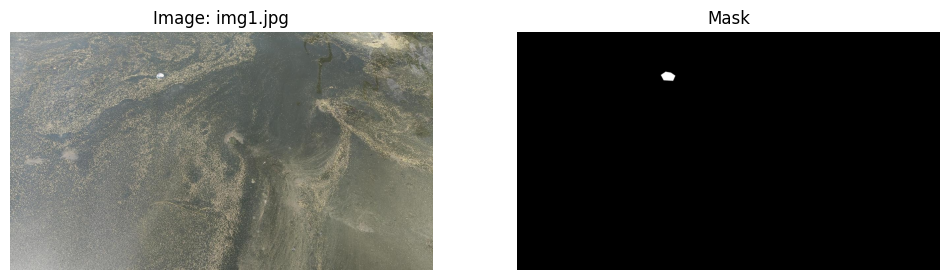

In [11]:
row = df.iloc[0]
image = cv2.imread(row["image_path"])
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

mask = cv2.imread(row["mask_path"], cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title(f"Image: {row['image_name']}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask, cmap="gray")
plt.title("Mask")
plt.axis("off")

plt.show()

## Data Splitting (70:15:15)

In [12]:
train_df, test_df = train_test_split(
    df,
    test_size=0.15,
    random_state=42,
    stratify=df["has_plastic"]
)

train_df, val_df = train_test_split(
    train_df,
    test_size=0.15,
    random_state=42,
    stratify=train_df["has_plastic"]
)

In [13]:
# reset
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train:", len(train_df))
print("Val  :", len(val_df))
print("Test :", len(test_df))

Train: 1445
Val  : 256
Test : 301


## Data Preprocessing

### Image Augmentation

In [24]:
IMAGE_HEIGHT = 512
IMAGE_WIDTH = 512
BATCH_SIZE = 4
NUM_CLASSES = 2
SEGFORMER_MODEL = "nvidia/mit-b3"


In [25]:
mean = (0.485, 0.456, 0.406)
std = (0.229, 0.224, 0.225)

In [26]:
# transform only training and validation images

train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.2, rotate_limit=30, p=0.5),
    A.OneOf([
        A.ElasticTransform(alpha=1, sigma=50, p=0.5),
        A.GridDistortion(p=0.5),
    ], p=0.3),
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.4),
    A.GaussNoise(std_range=(0.01, 0.05), p=0.3),
    A.CoarseDropout(
        num_holes_range=(1, 8),
        hole_height_range=(16, 32),
        hole_width_range=(16, 32),
        p=0.3
    ),
    A.Resize(IMAGE_HEIGHT, IMAGE_WIDTH),
    A.Normalize(mean=mean, std=std),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(IMAGE_HEIGHT, IMAGE_WIDTH),
    A.Normalize(mean=mean, std=std),
    ToTensorV2()
])

### Image Preprocessing (Class & Dataloader)

In [27]:
class FloPWDDataset(Dataset):
  def __init__(self, dataframe, transforms=None):
    self.dataframe = dataframe
    self.transforms = transforms

  def __len__(self):
    return len(self.dataframe)

  def __getitem__(self, idx):
    row = self.dataframe.iloc[idx]

    image = cv2.imread(row["image_path"])
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    mask = cv2.imread(row["mask_path"], cv2.IMREAD_GRAYSCALE)
    mask = (mask > 127).astype(np.uint8)  # 0 = background, 1 = plastic

    if self.transforms:
      transformed = self.transforms(image=image, mask=mask)
      image = transformed["image"]
      mask = transformed["mask"]

    # SegFormer + CrossEntropyLoss expects target shape [H, W] with dtype long.
    mask = mask.long()

    return image, mask


In [28]:
train_dataset = FloPWDDataset(train_df, transforms=train_transform)
val_dataset = FloPWDDataset(val_df, transforms=val_transform)
test_dataset = FloPWDDataset(test_df, transforms=val_transform)


In [29]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)


## Modelling

In [30]:
%%capture

model = SegformerForSemanticSegmentation.from_pretrained(
    SEGFORMER_MODEL,
    num_labels=NUM_CLASSES,
    ignore_mismatched_sizes=True
)


SegformerForSemanticSegmentation LOAD REPORT from: nvidia/mit-b3
Key                                           | Status     | 
----------------------------------------------+------------+-
classifier.weight                             | UNEXPECTED | 
classifier.bias                               | UNEXPECTED | 
decode_head.classifier.weight                 | MISSING    | 
decode_head.linear_c.{0, 1, 2, 3}.proj.bias   | MISSING    | 
decode_head.linear_c.{0, 1, 2, 3}.proj.weight | MISSING    | 
decode_head.batch_norm.running_mean           | MISSING    | 
decode_head.batch_norm.bias                   | MISSING    | 
decode_head.batch_norm.running_var            | MISSING    | 
decode_head.batch_norm.num_batches_tracked    | MISSING    | 
decode_head.linear_fuse.weight                | MISSING    | 
decode_head.batch_norm.weight                 | MISSING    | 
decode_head.classifier.bias                   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different ta

## Training

#### Training Hyperparameter

In [31]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

DEVICE

'cuda'

In [32]:
model = model.to(DEVICE)

#### Loss Function

##### Pos Weight Estimation for Class Imbalance Handlign

For Give more loss if positive pixel are predicted falsely (FP)

In [33]:
pos_pixels = 0
neg_pixels = 0

# step 1: sampling sebanyak 200
subset = train_df.sample(min(200, len(train_df)), random_state=42)

for _, row in subset.iterrows():
  mask = cv2.imread(row["mask_path"], cv2.IMREAD_GRAYSCALE)
  mask = (mask > 127).astype(np.uint8)

  pos_pixels += mask.sum()
  neg_pixels += mask.size - mask.sum()

pos_weight = neg_pixels / max(pos_pixels, 1)

pos_weight

np.float64(17.441991871195814)

##### BCE

Loss function for Clasification per pixel

In [34]:
# CrossEntropyLoss untuk SegFormer multi-class logits: [B, C, H, W].
# Class 0 = background, class 1 = plastic.
class_weights = torch.tensor([1.0, float(min(pos_weight, 50.0))], device=DEVICE)
ce_loss = nn.CrossEntropyLoss(weight=class_weights)

class_weights

tensor([ 1.0000, 17.4420], device='cuda:0')

##### DICE

Loss function for Mask Overlapping

In [35]:
def dice_loss(logits, targets, smooth=1.0):
  probs = torch.softmax(logits, dim=1)[:, 1, :, :]
  targets = targets.float()

  intersection = (probs * targets).sum(dim=(1, 2))
  union = probs.sum(dim=(1, 2)) + targets.sum(dim=(1, 2))

  dice = (2.0 * intersection + smooth) / (union + smooth)
  return 1.0 - dice.mean()


#####  Combine

In [36]:
def combined_loss(logits, targets, dice_weight=0.7, ce_weight=0.3):
  d_loss = dice_loss(logits, targets)
  c_loss = ce_loss(logits, targets)
  return dice_weight * d_loss + ce_weight * c_loss


#### Optimizer

In [37]:
encoder_params = list(model.segformer.parameters())
decoder_params = list(model.decode_head.parameters())

optimizer = torch.optim.AdamW([
    {"params": encoder_params, "lr": 1e-5},
    {"params": decoder_params, "lr": 3e-4},
], weight_decay=1e-4)

scaler = torch.amp.GradScaler("cuda", enabled=(DEVICE == "cuda"))


#### Metric

In [38]:
def apply_sigmoid(x):
  return torch.sigmoid(x)

In [39]:
def segformer_forward(model, images, target_size):
  outputs = model(pixel_values=images)
  logits = outputs.logits

  logits = F.interpolate(
      logits,
      size=target_size,
      mode="bilinear",
      align_corners=False
  )
  return logits


def binarize_mask(prob_mask, threshold=0.5):
  return (prob_mask > threshold).float()


In [40]:
def compute_stats(preds, targets, eps=1e-7):
  preds = preds.float()
  targets = targets.float()

  tp = (preds * targets).sum(dim=(1, 2))
  fp = (preds * (1 - targets)).sum(dim=(1, 2))
  fn = ((1 - preds) * targets).sum(dim=(1, 2))

  tn = ((1 - preds) * (1 - targets)).sum(dim=(1, 2))

  foreground_iou = (tp + eps) / (tp + fp + fn + eps)
  background_iou = (tn + eps) / (tn + fp + fn + eps)
  miou = (foreground_iou + background_iou) / 2.0

  dice = (2 * tp + eps) / (2 * tp + fp + fn + eps)
  precision = (tp + eps) / (tp + fp + eps)
  recall = (tp + eps) / (tp + fn + eps)

  return {
      "iou": foreground_iou.mean().item(),
      "foreground_iou": foreground_iou.mean().item(),
      "background_iou": background_iou.mean().item(),
      "miou": miou.mean().item(),
      "dice": dice.mean().item(),
      "precision": precision.mean().item(),
      "recall": recall.mean().item()
  }


In [41]:
def train_one_epoch(model, loader, optimizer, device):
    model.train()
    running_loss = 0.0

    pbar = tqdm(loader, desc="Training", leave=False)

    for images, masks in pbar:
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        optimizer.zero_grad()

        with torch.amp.autocast("cuda", enabled=(device == "cuda")):
            logits = segformer_forward(model, images, target_size=(masks.shape[1], masks.shape[2]))
            loss = combined_loss(logits, masks)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        pbar.set_postfix(loss=loss.item())

    return running_loss / len(loader)


In [42]:
def validate_one_epoch(model, loader, device, threshold=0.5):
    model.eval()

    running_loss = 0.0
    iou_scores = []
    foreground_iou_scores = []
    background_iou_scores = []
    miou_scores = []
    dice_scores = []
    precision_scores = []
    recall_scores = []

    with torch.no_grad():
        for images, masks in tqdm(loader, desc="Validation", leave=False):
            images = images.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)

            logits = segformer_forward(model, images, target_size=(masks.shape[1], masks.shape[2]))
            loss = combined_loss(logits, masks)

            probs = torch.softmax(logits, dim=1)[:, 1, :, :]
            preds = binarize_mask(probs, threshold=threshold)

            stats = compute_stats(preds, masks)

            running_loss += loss.item()
            iou_scores.append(stats["iou"])
            foreground_iou_scores.append(stats["foreground_iou"])
            background_iou_scores.append(stats["background_iou"])
            miou_scores.append(stats["miou"])
            dice_scores.append(stats["dice"])
            precision_scores.append(stats["precision"])
            recall_scores.append(stats["recall"])

    return {
        "loss": running_loss / len(loader),
        "iou": np.mean(iou_scores),
        "foreground_iou": np.mean(foreground_iou_scores),
        "background_iou": np.mean(background_iou_scores),
        "miou": np.mean(miou_scores),
        "dice": np.mean(dice_scores),
        "precision": np.mean(precision_scores),
        "recall": np.mean(recall_scores)
    }


In [43]:
def find_best_threshold(model, loader, device):
    thresholds = np.arange(0.10, 0.91, 0.05)
    best_threshold = 0.5
    best_dice = -1

    model.eval()

    all_probs = []
    all_masks = []

    with torch.no_grad():
        for images, masks in tqdm(loader, desc="Collecting val probs", leave=False):
            images = images.to(device)
            masks = masks.to(device)

            logits = segformer_forward(model, images, target_size=(masks.shape[1], masks.shape[2]))
            probs = torch.softmax(logits, dim=1)[:, 1, :, :].cpu()

            all_probs.append(probs)
            all_masks.append(masks.cpu().float())

    all_probs = torch.cat(all_probs, dim=0)
    all_masks = torch.cat(all_masks, dim=0)

    for threshold in thresholds:
        preds = (all_probs > threshold).float()
        stats = compute_stats(preds, all_masks)
        if stats["dice"] > best_dice:
            best_dice = stats["dice"]
            best_threshold = threshold

    return best_threshold, best_dice


#### Training

In [44]:
EPOCHS = 30
PATIENCES = 5

In [45]:
best_val_dice = -1
best_model_path = "/content/best_flopwd_segformer_b3_miou.pth"

history = []
counter = 0


In [46]:
for epoch in range(EPOCHS):
    print(f"\nEpoch [{epoch+1}/{EPOCHS}]")

    train_loss = train_one_epoch(model, train_loader, optimizer, DEVICE)

    best_threshold, _ = find_best_threshold(model, val_loader, DEVICE)
    val_metrics = validate_one_epoch(model, val_loader, DEVICE, threshold=best_threshold)

    print(f"Train Loss        : {train_loss:.4f}")
    print(f"Val Loss          : {val_metrics['loss']:.4f}")
    print(f"Val Foreground IoU: {val_metrics['foreground_iou']:.4f}")
    print(f"Val Background IoU: {val_metrics['background_iou']:.4f}")
    print(f"Val mIoU          : {val_metrics['miou']:.4f}")
    print(f"Val Dice          : {val_metrics['dice']:.4f}")
    print(f"Val Precision     : {val_metrics['precision']:.4f}")
    print(f"Val Recall        : {val_metrics['recall']:.4f}")
    print(f"Best Threshold    : {best_threshold:.2f}")

    history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "val_loss": val_metrics["loss"],
        "val_iou": val_metrics["iou"],
        "val_foreground_iou": val_metrics["foreground_iou"],
        "val_background_iou": val_metrics["background_iou"],
        "val_miou": val_metrics["miou"],
        "val_dice": val_metrics["dice"],
        "val_precision": val_metrics["precision"],
        "val_recall": val_metrics["recall"],
        "best_threshold": float(best_threshold)
    })

    if val_metrics["dice"] > best_val_dice:
        best_val_dice = val_metrics["dice"]
        torch.save(model.state_dict(), best_model_path)
        print("Best model saved.")
        counter = 0
    else:
        counter += 1
        print(f"No improvement. Patience counter: {counter}/{PATIENCES}")

    if counter >= PATIENCES:
        print("Early stopping triggered.")
        break



Epoch [1/30]


Train Loss        : 0.5708
Val Loss          : 0.4442
Val Foreground IoU: 0.5027
Val Background IoU: 0.9589
Val mIoU          : 0.7308
Val Dice          : 0.6063
Val Precision     : 0.6643
Val Recall        : 0.7184
Best Threshold    : 0.85
Best model saved.

Epoch [2/30]


Train Loss        : 0.4306
Val Loss          : 0.3926
Val Foreground IoU: 0.5093
Val Background IoU: 0.9643
Val mIoU          : 0.7368
Val Dice          : 0.6128
Val Precision     : 0.6411
Val Recall        : 0.7502
Best Threshold    : 0.85
Best model saved.

Epoch [3/30]


Train Loss        : 0.3699
Val Loss          : 0.3212
Val Foreground IoU: 0.5877
Val Background IoU: 0.9645
Val mIoU          : 0.7761
Val Dice          : 0.6856
Val Precision     : 0.7263
Val Recall        : 0.7706
Best Threshold    : 0.85
Best model saved.

Epoch [4/30]


Train Loss        : 0.3327
Val Loss          : 0.3229
Val Foreground IoU: 0.5975
Val Background IoU: 0.9652
Val mIoU          : 0.7813
Val Dice          : 0.6975
Val Precision     : 0.7455
Val Recall        : 0.7560
Best Threshold    : 0.65
Best model saved.

Epoch [5/30]


...

Train Loss        : 0.2247
Val Loss          : 0.2455
Val Foreground IoU: 0.6584
Val Background IoU: 0.9585
Val mIoU          : 0.8084
Val Dice          : 0.7556
Val Precision     : 0.7775
Val Recall        : 0.8092
Best Threshold    : 0.90
No improvement. Patience counter: 1/5

Epoch [27/30]


Train Loss        : 0.2120
Val Loss          : 0.2553
Val Foreground IoU: 0.6657
Val Background IoU: 0.9618
Val mIoU          : 0.8137
Val Dice          : 0.7628
Val Precision     : 0.7818
Val Recall        : 0.8114
Best Threshold    : 0.45
No improvement. Patience counter: 2/5

Epoch [28/30]


Train Loss        : 0.2251
Val Loss          : 0.2453
Val Foreground IoU: 0.6688
Val Background IoU: 0.9602
Val mIoU          : 0.8145
Val Dice          : 0.7642
Val Precision     : 0.7865
Val Recall        : 0.8194
Best Threshold    : 0.90
No improvement. Patience counter: 3/5

Epoch [29/30]


Train Loss        : 0.2179
Val Loss          : 0.2408
Val Foreground IoU: 0.6703
Val Background IoU: 0.9674
Val mIoU          : 0.8189
Val Dice          : 0.7672
Val Precision     : 0.7887
Val Recall        : 0.8075
Best Threshold    : 0.85
No improvement. Patience counter: 4/5

Epoch [30/30]


Train Loss        : 0.2186
Val Loss          : 0.2472
Val Foreground IoU: 0.6695
Val Background IoU: 0.9640
Val mIoU          : 0.8168
Val Dice          : 0.7658
Val Precision     : 0.8028
Val Recall        : 0.8031
Best Threshold    : 0.80
No improvement. Patience counter: 5/5
Early stopping triggered.


##### Training History

In [47]:
history_df = pd.DataFrame(history)
history_df.to_csv("/content/flopwd_training_history.csv", index=False)
history_df.tail()

,epoch,train_loss,val_loss,val_iou,val_foreground_iou,val_background_iou,val_miou,val_dice,val_precision,val_recall,best_threshold
25,26,0.224687,0.245469,0.658357,0.658357,0.958521,0.808439,0.755566,0.777518,0.809237,0.90
26,27,0.211966,0.255289,0.665692,0.665692,0.961753,0.813722,0.762785,0.781763,0.811409,0.45
27,28,0.225132,0.245317,0.668827,0.668827,0.960167,0.814497,0.764249,0.786518,0.819362,0.90
28,29,0.217898,0.240835,0.670277,0.670277,0.967431,0.818854,0.767244,0.788739,0.807483,0.85
29,30,0.218583,0.247163,0.669542,0.669542,0.963964,0.816753,0.765788,0.802767,0.803094,0.80


##### Best Model

In [48]:
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))

<All keys matched successfully>

##### Best Threshold

In [49]:
best_threshold, best_dice = find_best_threshold(model, val_loader, DEVICE)

#### Save Model

In [ ]:
from transformers import AutoImageProcessor

processor = AutoImageProcessor.from_pretrained(SEGFORMER_MODEL)

In [ ]:
model.save_pretrained("segformer-plastic")
processor.save_pretrained("segformer-plastic")

#### Evaluation

In [50]:
test_metrics = validate_one_epoch(model, test_loader, DEVICE, threshold=best_threshold)

for k, v in test_metrics.items():
    print(f"{k}: {v:.4f}")

loss: 0.2503
iou: 0.6527
foreground_iou: 0.6527
background_iou: 0.9701
miou: 0.8114
dice: 0.7508
precision: 0.7812
recall: 0.7979


- Result

In [51]:
with open("/content/flopwd_test_metrics.json", "w") as f:
    json.dump(test_metrics, f, indent=4)

## Inferences

In [52]:
def denormalize_image(image_tensor, mean, std):
    image = image_tensor.permute(1, 2, 0).cpu().numpy()
    image = image * np.array(std) + np.array(mean)
    image = np.clip(image, 0, 1)
    return image

def show_predictions(model, dataset, device, threshold=0.5, num_samples=5):
    model.eval()
    indices = np.random.choice(len(dataset), size=num_samples, replace=False)

    plt.figure(figsize=(15, num_samples * 5))

    with torch.no_grad():
        for i, idx in enumerate(indices):
            image, mask = dataset[idx]

            input_tensor = image.unsqueeze(0).to(device)
            logits = segformer_forward(model, input_tensor, target_size=(mask.shape[0], mask.shape[1]))
            probs = torch.softmax(logits, dim=1)[:, 1, :, :]
            pred = (probs > threshold).float()

            image_np = denormalize_image(image, mean, std)
            mask_np = mask.cpu().numpy()
            pred_np = pred.squeeze().cpu().numpy()

            plt.subplot(num_samples, 3, i * 3 + 1)
            plt.imshow(image_np)
            plt.title("Image")
            plt.axis("off")

            plt.subplot(num_samples, 3, i * 3 + 2)
            plt.imshow(mask_np, cmap="gray")
            plt.title("Ground Truth")
            plt.axis("off")

            plt.subplot(num_samples, 3, i * 3 + 3)
            plt.imshow(pred_np, cmap="gray")
            plt.title("Prediction")
            plt.axis("off")

    plt.tight_layout()
    plt.show()


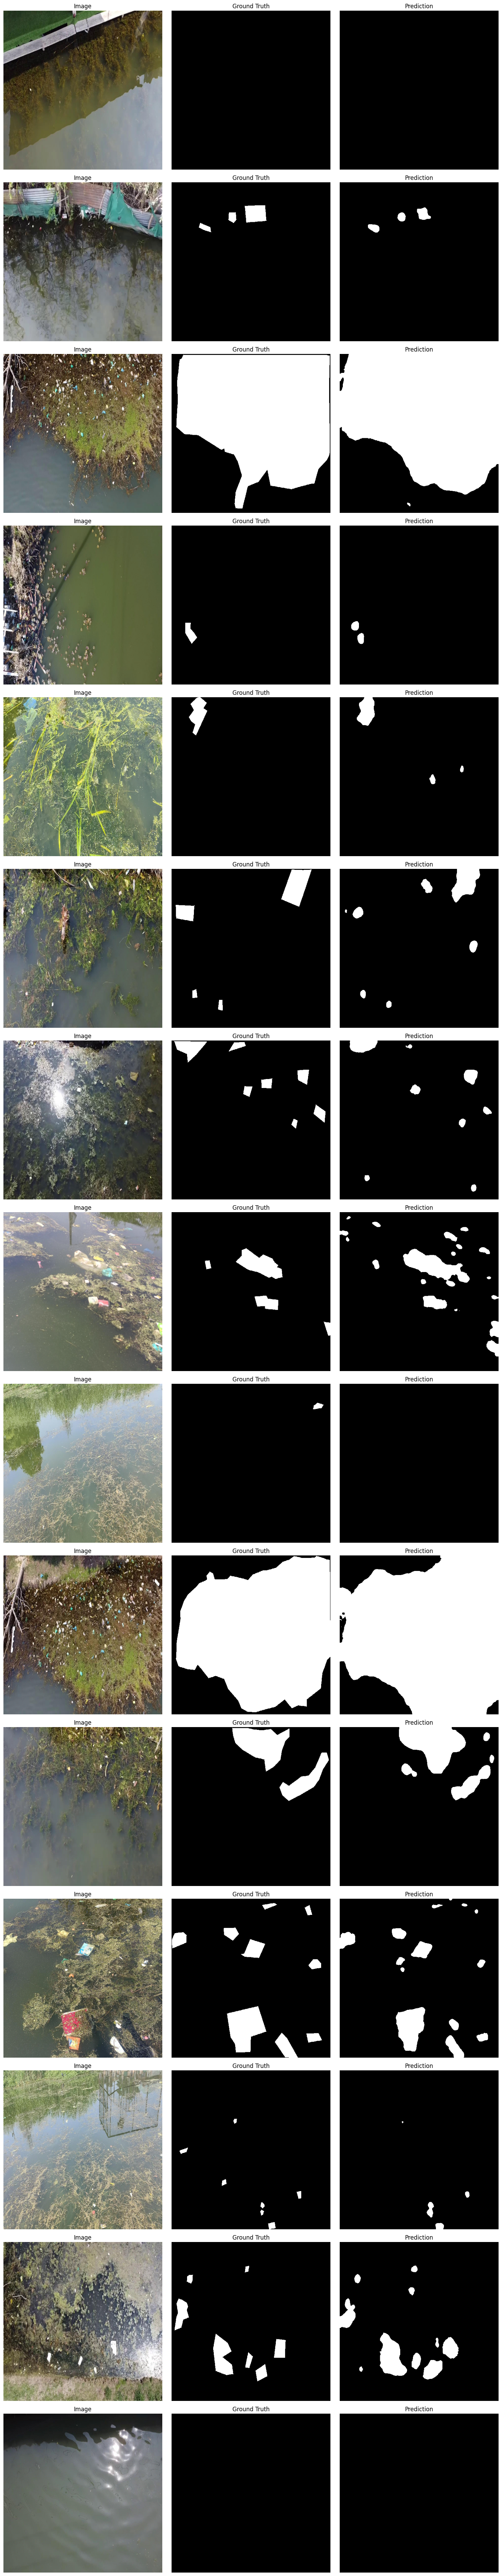

In [53]:
show_predictions(model, test_dataset, DEVICE, threshold=best_threshold, num_samples=15)